# Point 3, Decision Support, Decline Attribution

## Table Of Contents

- [1. The Problem And This Approach](#sec1)
- [2. Data Preparation](#sec2)
- [3. Computing Biomarker Slopes](#sec3)
- [4. Lasso On Slopes Instead Of Levels](#sec4)
- [5. How Much Would These Numbers Move](#sec5)
- [6. Saving The Standardized Result](#sec6)
- [7. Takeaways](#sec7)

<a id="sec1"></a>

## 1. The Problem And This Approach

The global attribution notebook in this folder ranks biomarkers by how strongly their current level predicts RISK_SCORE, on average across the whole cohort. That ranking treats every patient's biomarker reading as a single snapshot, it does not ask whether a biomarker got there slowly or quickly. A clinician thinking about where a specific patient is deteriorating cares about exactly that, is a biomarker not just low, but actively falling, since a biomarker that is already low but stable tells a different story than one dropping fast right now.

This notebook asks the same global attribution question as the first, which biomarkers drive RISK_SCORE, but from each patient's own rate of change instead of their raw level, the per month slope between consecutive visits, the same reframing the trajectory adaptive policy already applies to the interval choosing question, applied here to attribution instead. A third notebook in this folder drops RISK_SCORE altogether and checks the same biomarkers against a real recorded worsening event instead of against either placeholder ranking here.

Like every approach notebook in this project, this one is self sufficient, it loads the data, computes its own slopes, fits its own model, and appends one standardized row per split to results/decision_support/approach_comparison.csv, read later by comparison.ipynb alongside every other approach.

In [1]:
# ============================================================
# Notebook setup
# ============================================================

%load_ext autoreload
%autoreload 2

figsize = (14, 4)

import os
import sys
sys.path.append(os.path.join('..', '..', '..'))

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

from util import decision_util as du

data_folder = os.path.join('..', '..', '..', 'datasets')
data_path = os.path.join(data_folder, 'final.csv')
results_path = os.path.join('..', '..', '..', 'results', 'decision_support')
os.makedirs(results_path, exist_ok=True)

<a id="sec2"></a>

## 2. Data Preparation

The cell below loads datasets/final.csv, the single table produced by merging Point 1's imaging derived measures with the clinical and diagnostic fields, one row per patient per visit, keyed by RID and the normalized visit code. The same seven biomarkers used throughout this project, HIPPO_NORM, ENTORHINAL_NORM, AMYGDALA_NORM, SUMMARY_SUVR, ABETA_RATIO, TAU, and PTAU, are forward filled per patient first, carrying each patient's most recently known value forward to later visits, so a visit without a fresh scan or panel can still be scored using the last one that was taken.

RISK_SCORE here is HAZARD_ESTIMATE, point two's own multi visit discrete time hazard model, results/hazard_model/hazard_estimates.csv, wherever that estimate exists, the same swap already made in temporal_window/1 through temporal_window/4 and in risk_factors/1_global.ipynb, with the same fallback estimator, a plain Logistic Regression fit on DIAGNOSIS and AMYLOID_STATUS categories alone, filling the rows HAZARD_ESTIMATE does not reach. The subject level split into train and test happens further down, after each biomarker's own slope has been computed, so both splits already carry a slope column wherever one is available, and the swap itself lands right after that split too, in the same cell that already reports slope coverage, since the fallback estimator needs DIAGNOSIS_WORSENED_NEXT computed separately on each split.

In [2]:
data = pd.read_csv(data_path)

biomarker_cols = [
    'HIPPO_NORM', 'ENTORHINAL_NORM', 'AMYGDALA_NORM',
    'SUMMARY_SUVR', 'ABETA_RATIO', 'TAU', 'PTAU',
]
data = du.forward_fill_by_patient(
    data, biomarker_cols, id_col='RID', date_col='EXAMDATE_DX',
)

# RISK_SCORE itself is assigned in the next cell, after the train and
# test split, since the fallback estimator it needs is fit separately
# on each split, the same reason temporal_window/2_snapshot_adaptive.ipynb
# and risk_factors/1_global.ipynb also assign it after their own split.

<a id="sec3"></a>

## 3. Computing Biomarker Slopes

compute_biomarker_slopes looks, for every row, for that same patient's immediately preceding visit, sorted by EXAMDATE_DX, and returns one new column per biomarker, named f'{biomarker}_SLOPE', the change in that biomarker per month between those two visits. HAS_SLOPE_HISTORY marks whether at least one of those slope columns has a usable value for that row, a patient's very first observed visit has nothing earlier to compare against, so every slope column is NaN there.

The subject level split into train and test, random_state=42 like every other approach notebook in this project, happens right after, so the coverage reported below, how many rows in each split actually have a usable slope, is measured on the same two splits the Lasso fit further down will train and test on.

In [3]:
data = du.compute_biomarker_slopes(
    data, biomarker_cols, id_col='RID', date_col='EXAMDATE_DX',
)
slope_cols = [f'{col}_SLOPE' for col in biomarker_cols]

data['DIAGNOSIS_MCI'] = (data['DIAGNOSIS'] == 2).astype(float)
data['DIAGNOSIS_DEMENTIA'] = (data['DIAGNOSIS'] == 3).astype(float)
data['AMYLOID_POSITIVE'] = (data['AMYLOID_STATUS'] == 1).astype(float)
data['AMYLOID_UNKNOWN'] = data['AMYLOID_STATUS'].isna().astype(float)
hazard_features = ['DIAGNOSIS_MCI', 'DIAGNOSIS_DEMENTIA', 'AMYLOID_POSITIVE', 'AMYLOID_UNKNOWN']

train_df, test_df = du.subject_train_test_split(data, test_fraction=0.25, random_state=42)
train_df = train_df.copy()
test_df = test_df.copy()
print(f'Train, {train_df.shape[0]} rows, {train_df.RID.nunique()} patients')
print(f'Test,  {test_df.shape[0]} rows, {test_df.RID.nunique()} patients')

train_coverage = train_df['HAS_SLOPE_HISTORY'].mean() * 100
test_coverage = test_df['HAS_SLOPE_HISTORY'].mean() * 100
print(f'Train, {train_coverage:.1f} percent of rows have at least one usable slope')
print(f'Test,  {test_coverage:.1f} percent of rows have at least one usable slope')

# SWAP POINT: point two now exists, results/hazard_model/hazard_estimates.csv
# holds HAZARD_ESTIMATE from a real multi visit discrete time survival
# model, hazard_survival_model.ipynb, following 05 pm, lesson 6, directly,
# fit on structural MRI, amyloid PET, and cerebrospinal fluid together
# rather than on DIAGNOSIS and AMYLOID_STATUS alone. Coverage is not
# complete on the full dataset, so RISK_SCORE below takes HAZARD_ESTIMATE
# wherever it exists and keeps the fallback estimator only for the rows
# it does not reach, the same pattern risk_factors/1_global.ipynb uses.
fallback_train_outcomes = du.compute_diagnosis_worsening(
    train_df, id_col='RID', date_col='EXAMDATE_DX', diagnosis_col='DIAGNOSIS',
)
fallback_test_outcomes = du.compute_diagnosis_worsening(
    test_df, id_col='RID', date_col='EXAMDATE_DX', diagnosis_col='DIAGNOSIS',
)
fallback_train_data = fallback_train_outcomes[fallback_train_outcomes['HAS_NEXT_VISIT']]
fallback_test_data = fallback_test_outcomes[fallback_test_outcomes['HAS_NEXT_VISIT']]

fallback_model, fallback_scaler = du.fit_logistic_baseline(
    fallback_train_data[hazard_features],
    fallback_train_data['DIAGNOSIS_WORSENED_NEXT'],
)

train_df['FALLBACK_RISK_SCORE'] = fallback_model.predict_proba(fallback_scaler.transform(train_df[hazard_features]))[:, 1]
test_df['FALLBACK_RISK_SCORE'] = fallback_model.predict_proba(fallback_scaler.transform(test_df[hazard_features]))[:, 1]

hazard_estimates_path = os.path.join('..', '..', '..', 'results', 'hazard_model', 'hazard_estimates.csv')
hazard_estimates = pd.read_csv(hazard_estimates_path)[['RID', 'VISCODE2_norm', 'HAZARD_ESTIMATE']]

train_df = train_df.merge(hazard_estimates, on=['RID', 'VISCODE2_norm'], how='left')
test_df = test_df.merge(hazard_estimates, on=['RID', 'VISCODE2_norm'], how='left')

train_df['RISK_SCORE'] = train_df['HAZARD_ESTIMATE'].fillna(train_df['FALLBACK_RISK_SCORE'])
test_df['RISK_SCORE'] = test_df['HAZARD_ESTIMATE'].fillna(test_df['FALLBACK_RISK_SCORE'])

Train, 10162 rows, 2832 patients
Test,  3665 rows, 945 patients
Train, 72.1 percent of rows have at least one usable slope
Test,  74.1 percent of rows have at least one usable slope


<a id="sec4"></a>

## 4. Lasso, Random Forest, And SHAP On Slopes Instead Of Levels

Rows missing every slope, a patient's own first visit, are dropped here the same way risk_factors/1_global.ipynb drops rows missing a raw biomarker, this notebook cannot attribute anything to a slope that does not exist for that row. The seven slope columns already exclude PTGENDER, PTEDUCAT, and PTMARRY by construction, none of them are biomarkers, so the same fairness boundary risk_factors/1_global.ipynb enforces explicitly is automatic here.

Both a Lasso and a Random Forest are fit here on the seven slope columns, the same linear against nonlinear comparison risk_factors/1_global.ipynb already runs on raw levels, now run on each biomarker's own rate of change instead. Lasso gives a signed reading of which biomarker's rate of change pushes RISK_SCORE up or down the most, and by how much per unit of monthly change, the Random Forest can capture interactions and thresholds a linear model cannot, at the cost of that signed, per unit reading. SHAP is added as a third vantage point on the fitted Random Forest itself, the same compute_shap_importance function risk_factors/1_global.ipynb calls, following 06 at, lesson 4, Additive Feature Attribution. R squared and mean absolute error on train and on test below are directly comparable to risk_factors/1_global.ipynb's own Lasso and Random Forest rows, all are the same two model classes fit on the same target, only the inputs differ, level against speed.

In [4]:
train_model_data = train_df.dropna(subset=slope_cols + ['RISK_SCORE'])
test_model_data = test_df.dropna(subset=slope_cols + ['RISK_SCORE'])

train_hazard_coverage = train_model_data['HAZARD_ESTIMATE'].notna().mean() * 100
test_hazard_coverage = test_model_data['HAZARD_ESTIMATE'].notna().mean() * 100
print(f'Train, {train_hazard_coverage:.1f} percent of the slope complete rows used below carry a real HAZARD_ESTIMATE, '
      f'the rest use the fallback estimator.')
print(f'Test,  {test_hazard_coverage:.1f} percent of the slope complete rows used below carry a real HAZARD_ESTIMATE, '
      f'the rest use the fallback estimator.')

slope_model, slope_scaler = du.fit_lasso_baseline(
    train_model_data[slope_cols],
    train_model_data['RISK_SCORE'],
    alpha=0.01,
)
slope_forest_model = du.fit_forest_baseline(
    train_model_data[slope_cols],
    train_model_data['RISK_SCORE'],
    n_estimators=200,
    max_depth=4,
)

slope_train_metrics = du.evaluate_regression(slope_model, train_model_data[slope_cols], train_model_data['RISK_SCORE'], scaler=slope_scaler)
slope_test_metrics = du.evaluate_regression(slope_model, test_model_data[slope_cols], test_model_data['RISK_SCORE'], scaler=slope_scaler)
slope_forest_train_metrics = du.evaluate_regression(slope_forest_model, train_model_data[slope_cols], train_model_data['RISK_SCORE'])
slope_forest_test_metrics = du.evaluate_regression(slope_forest_model, test_model_data[slope_cols], test_model_data['RISK_SCORE'])

slope_comparison = pd.DataFrame([
    {'method': 'Lasso on slopes', 'split': 'train', **slope_train_metrics},
    {'method': 'Lasso on slopes', 'split': 'test', **slope_test_metrics},
    {'method': 'Random Forest on slopes', 'split': 'train', **slope_forest_train_metrics},
    {'method': 'Random Forest on slopes', 'split': 'test', **slope_forest_test_metrics},
])
slope_comparison

Train, 99.1 percent of the slope complete rows used below carry a real HAZARD_ESTIMATE, the rest use the fallback estimator.
Test,  99.5 percent of the slope complete rows used below carry a real HAZARD_ESTIMATE, the rest use the fallback estimator.


,method,split,r2,mae
0,Lasso on slopes,train,0.129765,0.135760
1,Lasso on slopes,test,0.088417,0.144425
2,Random Forest on slopes,train,0.352110,0.115124
3,Random Forest on slopes,test,0.157534,0.132712


/sessions/rcw-01txmlmwkufouuaxcrpb7vcf/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


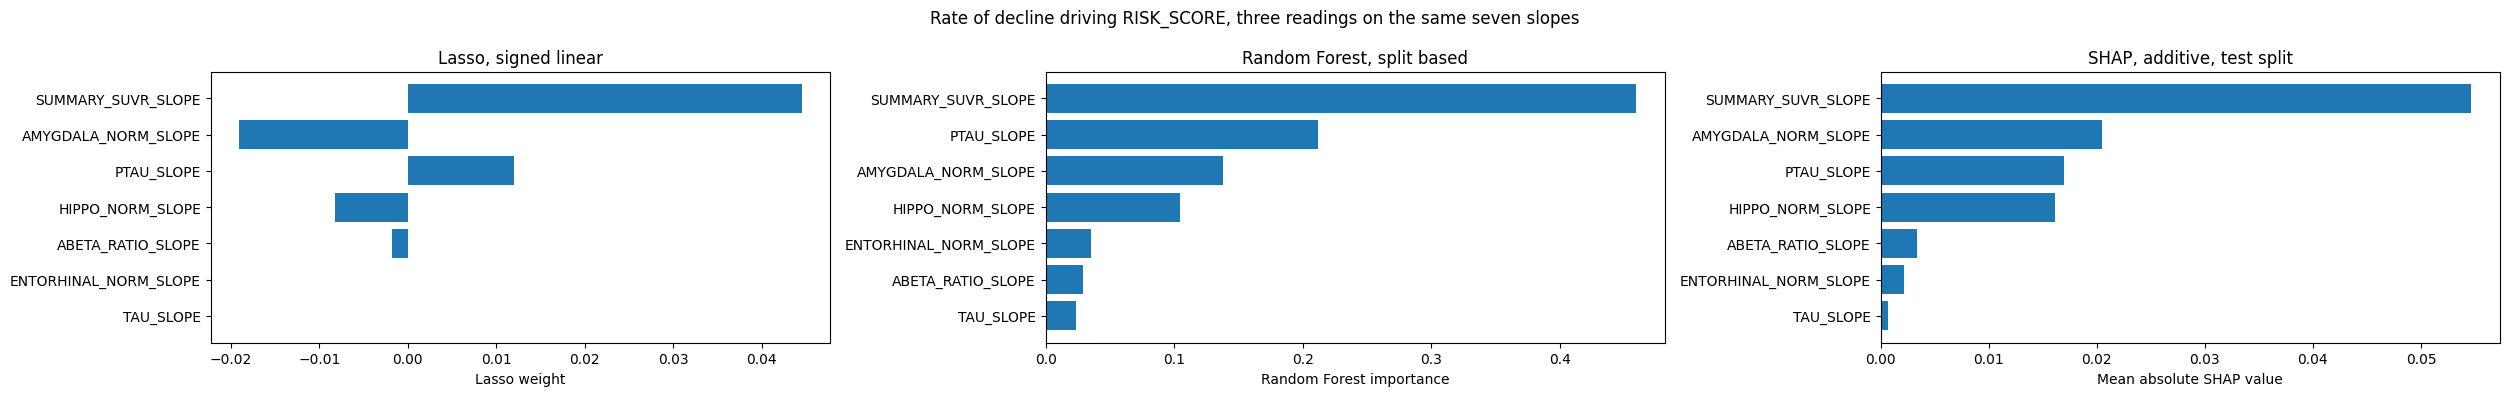

,feature,mean_abs_shap
0,SUMMARY_SUVR_SLOPE,0.054587
1,AMYGDALA_NORM_SLOPE,0.020503
2,PTAU_SLOPE,0.016955
3,HIPPO_NORM_SLOPE,0.016099
4,ABETA_RATIO_SLOPE,0.003326
5,ENTORHINAL_NORM_SLOPE,0.002151
6,TAU_SLOPE,0.000702


In [5]:
slope_weights = du.top_lasso_weights(slope_model, slope_cols, top_n=7)
slope_forest_importances = pd.DataFrame({
    'feature': slope_cols,
    'importance': slope_forest_model.feature_importances_,
}).sort_values('importance', ascending=False).reset_index(drop=True)
slope_mean_abs_shap, slope_shap_values = du.compute_shap_importance(slope_forest_model, test_model_data[slope_cols], slope_cols)

fig, axes = plt.subplots(1, 3, figsize=(figsize[0] * 1.8, figsize[1]))

axes[0].barh(slope_weights['feature'], slope_weights['weight'])
axes[0].set_xlabel('Lasso weight')
axes[0].set_title('Lasso, signed linear')
axes[0].invert_yaxis()

axes[1].barh(slope_forest_importances['feature'], slope_forest_importances['importance'])
axes[1].set_xlabel('Random Forest importance')
axes[1].set_title('Random Forest, split based')
axes[1].invert_yaxis()

axes[2].barh(slope_mean_abs_shap['feature'], slope_mean_abs_shap['mean_abs_shap'])
axes[2].set_xlabel('Mean absolute SHAP value')
axes[2].set_title('SHAP, additive, test split')
axes[2].invert_yaxis()

fig.suptitle('Rate of decline driving RISK_SCORE, three readings on the same seven slopes')
plt.tight_layout()
plt.show()

# Biomarker names are saved at their base form here, stripping the own
# _SLOPE suffix, so comparison.ipynb can line these rankings up against
# risk_factors/1_global.ipynb's own level based ranking, biomarker by
# biomarker, on the same underlying eight, seven once AGE is excluded.
def base_biomarker_name(series):
    renamed = series.copy()
    renamed.index = renamed.index.str.replace('_SLOPE', '', regex=False)
    return renamed

du.append_biomarker_ranking(results_path, '2_decline', 'lasso', base_biomarker_name(slope_weights.set_index('feature')['weight']))
du.append_biomarker_ranking(results_path, '2_decline', 'random_forest', base_biomarker_name(slope_forest_importances.set_index('feature')['importance']))
du.append_biomarker_ranking(results_path, '2_decline', 'shap', base_biomarker_name(slope_mean_abs_shap.set_index('feature')['mean_abs_shap']))

slope_mean_abs_shap

### 4.1 How Much Would These Weights Themselves Move

Section 5 below bootstraps r2 and mae by scoring the same already fitted model again on each resample, appropriate there since the question is how much the model's own accuracy would move with a different patient sample, not how much the model itself would change. A slope weight has no such fixed point to reuse, the weight only exists once a model has actually been fit, so this subsection refits Lasso and the Random Forest inside every one of 150 resamples instead, using bootstrap_attribution_weights from util/decision_util.py, the same function risk_factors/1_global.ipynb's own subsection 3.2 already uses.

train_model_data here is far smaller than risk_factors/1_global.ipynb's own, 1627 rows across 379 patients rather than 2048 rows across 414, so the Random Forest fit inside the bootstrap still uses 25 trees rather than section 4's own 200, the same speed for precision tradeoff, but SHAP inside the bootstrap explains each resample's own full slope_cols columns rather than a fixed row subset, the whole resample here is already smaller than the fixed subset risk_factors/1_global.ipynb needs. Section 4's own point estimates above still come from the full 200 tree model, only this subsection's own bootstrap loop trades tree count for speed.

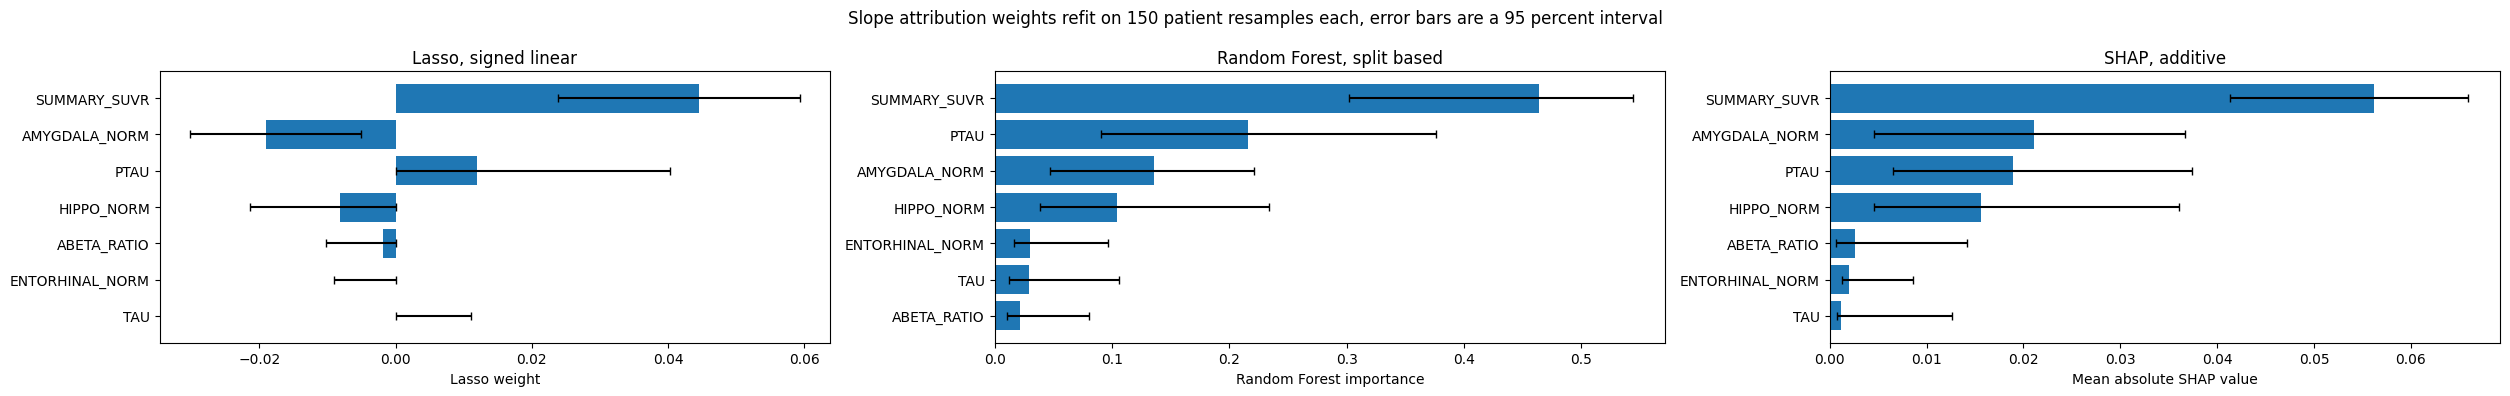

,feature,point,lower,upper,n_bootstrap
0,HIPPO_NORM,-0.008192,-0.021406,0.000000,150
1,ENTORHINAL_NORM,-0.000000,-0.009061,0.000000,150
2,AMYGDALA_NORM,-0.019085,-0.030140,-0.005057,150
3,SUMMARY_SUVR,0.044549,0.023915,0.059299,150
4,ABETA_RATIO,-0.001789,-0.010238,0.000000,150
5,TAU,0.000000,0.000000,0.011128,150
6,PTAU,0.011957,0.000000,0.040242,150


In [6]:
def lasso_fit_fn(d):
    return du.fit_lasso_baseline(d[slope_cols], d['RISK_SCORE'], alpha=0.01)

def lasso_weight_fn(fitted, d):
    model, scaler = fitted
    return pd.Series(model.coef_, index=slope_cols)

def bootstrap_forest_fit_fn(d):
    return du.fit_forest_baseline(d[slope_cols], d['RISK_SCORE'], n_estimators=25, max_depth=4)

def forest_weight_fn(fitted, d):
    return pd.Series(fitted.feature_importances_, index=slope_cols)

def shap_weight_fn(fitted, d):
    mean_abs_shap, _ = du.compute_shap_importance(fitted, d[slope_cols], slope_cols)
    return mean_abs_shap.set_index('feature')['mean_abs_shap']

lasso_slope_weight_ci = du.bootstrap_attribution_weights(train_model_data, lasso_fit_fn, lasso_weight_fn, id_col='RID', n_bootstrap=150)
forest_slope_weight_ci = du.bootstrap_attribution_weights(train_model_data, bootstrap_forest_fit_fn, forest_weight_fn, id_col='RID', n_bootstrap=150)
shap_slope_weight_ci = du.bootstrap_attribution_weights(train_model_data, bootstrap_forest_fit_fn, shap_weight_fn, id_col='RID', n_bootstrap=150)

lasso_slope_weight_ci = lasso_slope_weight_ci.assign(feature=lasso_slope_weight_ci['feature'].str.replace('_SLOPE', '', regex=False))
forest_slope_weight_ci = forest_slope_weight_ci.assign(feature=forest_slope_weight_ci['feature'].str.replace('_SLOPE', '', regex=False))
shap_slope_weight_ci = shap_slope_weight_ci.assign(feature=shap_slope_weight_ci['feature'].str.replace('_SLOPE', '', regex=False))

fig, axes = plt.subplots(1, 3, figsize=(figsize[0] * 1.8, figsize[1]))

for ax, ci_table, xlabel, title in [
    (axes[0], lasso_slope_weight_ci, 'Lasso weight', 'Lasso, signed linear'),
    (axes[1], forest_slope_weight_ci, 'Random Forest importance', 'Random Forest, split based'),
    (axes[2], shap_slope_weight_ci, 'Mean absolute SHAP value', 'SHAP, additive'),
]:
    ordered = ci_table.reindex(ci_table['point'].abs().sort_values(ascending=False).index)
    err_lower = (ordered['point'] - ordered['lower']).clip(lower=0)
    err_upper = (ordered['upper'] - ordered['point']).clip(lower=0)
    ax.barh(ordered['feature'], ordered['point'], xerr=[err_lower, err_upper], capsize=3)
    ax.set_xlabel(xlabel)
    ax.set_title(title)
    ax.invert_yaxis()

fig.suptitle('Slope attribution weights refit on 150 patient resamples each, error bars are a 95 percent interval')
plt.tight_layout()
plt.show()

lasso_slope_weight_ci

**Read an error bar that crosses zero as this project not currently able to rule out that a biomarker's own true slope weight is zero, on this particular patient sample.** train_model_data here carries far fewer patients than risk_factors/1_global.ipynb's own, 379 against 414, so wider intervals here than there are expected on that count alone, not necessarily a sign the rate of decline attribution is inherently less trustworthy than the level based one. Whichever biomarkers keep an interval clearly apart from zero across all three methods here are the ones this notebook's own smaller patient count still supports confidently, worth reading directly against risk_factors/1_global.ipynb's own subsection 3.2 for the same biomarker, level against speed, exactly as section 5 below already asks for r2 and mae.

<a id="sec5"></a>

## 5. How Much Would These Numbers Move

The R squared and mean absolute error above come from one fixed train and test split. bootstrap_ci resamples patients with replacement 400 times, a patient's own full set of rows moves together since two visits from one patient are not two independent draws, scores the same already fitted model again on each resample without ever refitting it, and reads the 2.5th and 97.5th percentile as a 95 percent interval, now computed separately for Lasso and for the Random Forest, the same pairing risk_factors/1_global.ipynb already reports for its own two models.

Worth reading directly against risk_factors/1_global.ipynb's own Lasso and Random Forest intervals from its own section on the same question, if the matching pair of intervals overlap heavily, level and speed of decline are not clearly separable on how well either predicts RISK_SCORE, only their point estimates would be, which is a weaker claim.

Lasso on slopes,         train, r2 0.130, 95% CI [0.076, 0.171], mae 0.136, 95% CI [0.126, 0.146]
Lasso on slopes,         test,  r2 0.088, 95% CI [0.005, 0.147], mae 0.144, 95% CI [0.129, 0.162]
Random Forest on slopes, train, r2 0.352, 95% CI [0.294, 0.402], mae 0.115, 95% CI [0.106, 0.124]
Random Forest on slopes, test,  r2 0.158, 95% CI [0.022, 0.260], mae 0.133, 95% CI [0.118, 0.151]


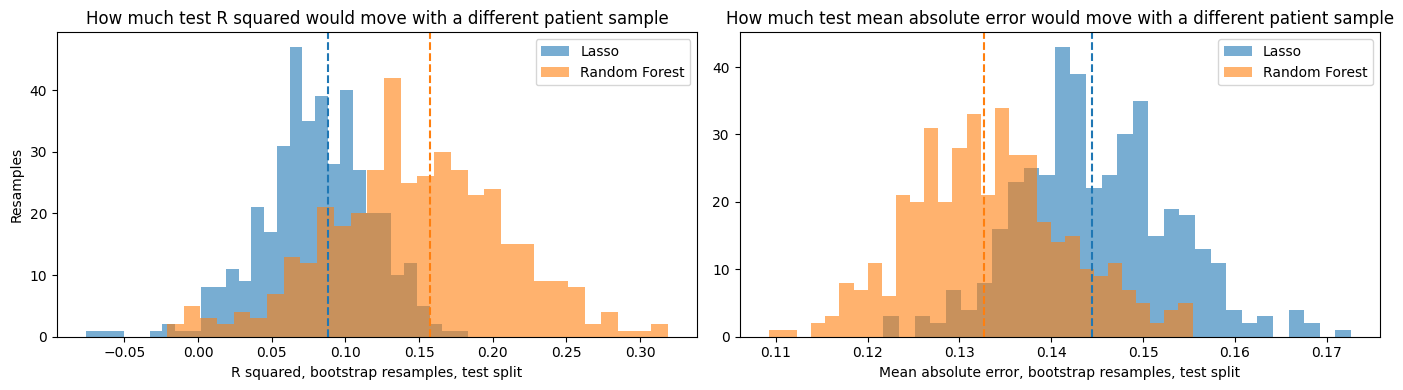

In [1]:
def make_r2_metric(model, scaler=None):
    def metric(d):
        return du.evaluate_regression(model, d[slope_cols], d['RISK_SCORE'], scaler=scaler)['r2']
    return metric

def make_mae_metric(model, scaler=None):
    def metric(d):
        return du.evaluate_regression(model, d[slope_cols], d['RISK_SCORE'], scaler=scaler)['mae']
    return metric

slope_train_r2_point, slope_train_r2_lo, slope_train_r2_hi, slope_train_r2_samples = du.bootstrap_ci(train_model_data, make_r2_metric(slope_model, slope_scaler), id_col='RID')
slope_train_mae_point, slope_train_mae_lo, slope_train_mae_hi, slope_train_mae_samples = du.bootstrap_ci(train_model_data, make_mae_metric(slope_model, slope_scaler), id_col='RID')
slope_test_r2_point, slope_test_r2_lo, slope_test_r2_hi, slope_test_r2_samples = du.bootstrap_ci(test_model_data, make_r2_metric(slope_model, slope_scaler), id_col='RID')
slope_test_mae_point, slope_test_mae_lo, slope_test_mae_hi, slope_test_mae_samples = du.bootstrap_ci(test_model_data, make_mae_metric(slope_model, slope_scaler), id_col='RID')

slope_forest_train_r2_point, slope_forest_train_r2_lo, slope_forest_train_r2_hi, _ = du.bootstrap_ci(train_model_data, make_r2_metric(slope_forest_model), id_col='RID')
slope_forest_train_mae_point, slope_forest_train_mae_lo, slope_forest_train_mae_hi, _ = du.bootstrap_ci(train_model_data, make_mae_metric(slope_forest_model), id_col='RID')
slope_forest_test_r2_point, slope_forest_test_r2_lo, slope_forest_test_r2_hi, slope_forest_test_r2_samples = du.bootstrap_ci(test_model_data, make_r2_metric(slope_forest_model), id_col='RID')
slope_forest_test_mae_point, slope_forest_test_mae_lo, slope_forest_test_mae_hi, slope_forest_test_mae_samples = du.bootstrap_ci(test_model_data, make_mae_metric(slope_forest_model), id_col='RID')

print(f'Lasso on slopes,         train, r2 {slope_train_r2_point:.3f}, 95% CI [{slope_train_r2_lo:.3f}, {slope_train_r2_hi:.3f}], '
      f'mae {slope_train_mae_point:.3f}, 95% CI [{slope_train_mae_lo:.3f}, {slope_train_mae_hi:.3f}]')
print(f'Lasso on slopes,         test,  r2 {slope_test_r2_point:.3f}, 95% CI [{slope_test_r2_lo:.3f}, {slope_test_r2_hi:.3f}], '
      f'mae {slope_test_mae_point:.3f}, 95% CI [{slope_test_mae_lo:.3f}, {slope_test_mae_hi:.3f}]')
print(f'Random Forest on slopes, train, r2 {slope_forest_train_r2_point:.3f}, 95% CI [{slope_forest_train_r2_lo:.3f}, {slope_forest_train_r2_hi:.3f}], '
      f'mae {slope_forest_train_mae_point:.3f}, 95% CI [{slope_forest_train_mae_lo:.3f}, {slope_forest_train_mae_hi:.3f}]')
print(f'Random Forest on slopes, test,  r2 {slope_forest_test_r2_point:.3f}, 95% CI [{slope_forest_test_r2_lo:.3f}, {slope_forest_test_r2_hi:.3f}], '
      f'mae {slope_forest_test_mae_point:.3f}, 95% CI [{slope_forest_test_mae_lo:.3f}, {slope_forest_test_mae_hi:.3f}]')

fig, axes = plt.subplots(1, 2, figsize=figsize)

axes[0].hist(slope_test_r2_samples, bins=30, alpha=0.6, label='Lasso')
axes[0].hist(slope_forest_test_r2_samples, bins=30, alpha=0.6, label='Random Forest')
axes[0].axvline(slope_test_r2_point, color='C0', linestyle='--')
axes[0].axvline(slope_forest_test_r2_point, color='C1', linestyle='--')
axes[0].set_xlabel('R squared, bootstrap resamples, test split')
axes[0].set_ylabel('Resamples')
axes[0].set_title('How much test R squared would move with a different patient sample')
axes[0].legend()

axes[1].hist(slope_test_mae_samples, bins=30, alpha=0.6, label='Lasso')
axes[1].hist(slope_forest_test_mae_samples, bins=30, alpha=0.6, label='Random Forest')
axes[1].axvline(slope_test_mae_point, color='C0', linestyle='--')
axes[1].axvline(slope_forest_test_mae_point, color='C1', linestyle='--')
axes[1].set_xlabel('Mean absolute error, bootstrap resamples, test split')
axes[1].set_title('How much test mean absolute error would move with a different patient sample')
axes[1].legend()

plt.tight_layout()
plt.show()

<a id="sec6"></a>

## 6. Saving The Standardized Result

Four rows now, two models times two splits, appended to the shared results/decision_support/approach_comparison.csv under the same attribution group risk_factors/1_global.ipynb and risk_factors/3_real_outcome.ipynb also write to, read later by comparison.ipynb alongside those. Lasso keeps its existing approach name, decline_attribution, so every earlier run's own two rows stay valid, the Random Forest is logged separately as decline_attribution_forest. append_approach_result is idempotent per approach and split, rerunning this notebook replaces its own four rows rather than piling up duplicates. The confidence intervals from the section above are logged alongside the point estimates.

In [2]:
train_ci = {'r2': (slope_train_r2_lo, slope_train_r2_hi), 'mae': (slope_train_mae_lo, slope_train_mae_hi)}
test_ci = {'r2': (slope_test_r2_lo, slope_test_r2_hi), 'mae': (slope_test_mae_lo, slope_test_mae_hi)}
forest_train_ci = {'r2': (slope_forest_train_r2_lo, slope_forest_train_r2_hi), 'mae': (slope_forest_train_mae_lo, slope_forest_train_mae_hi)}
forest_test_ci = {'r2': (slope_forest_test_r2_lo, slope_forest_test_r2_hi), 'mae': (slope_forest_test_mae_lo, slope_forest_test_mae_hi)}

du.append_approach_result(
    results_path, approach='decline_attribution', approach_group='attribution',
    split='train', n_rows=len(train_model_data),
    r2=slope_train_metrics['r2'], mae=slope_train_metrics['mae'], ci=train_ci,
    notes=f'Lasso on per month biomarker slopes rather than raw levels, alpha=0.01, train coverage {train_coverage:.1f} percent.',
)
du.append_approach_result(
    results_path, approach='decline_attribution', approach_group='attribution',
    split='test', n_rows=len(test_model_data),
    r2=slope_test_metrics['r2'], mae=slope_test_metrics['mae'], ci=test_ci,
    notes=f'Lasso on per month biomarker slopes rather than raw levels, alpha=0.01, test coverage {test_coverage:.1f} percent.',
)
du.append_approach_result(
    results_path, approach='decline_attribution_forest', approach_group='attribution',
    split='train', n_rows=len(train_model_data),
    r2=slope_forest_train_metrics['r2'], mae=slope_forest_train_metrics['mae'], ci=forest_train_ci,
    notes=f'Random Forest on per month biomarker slopes, 200 trees, max depth 4, train coverage {train_coverage:.1f} percent.',
)
result_row = du.append_approach_result(
    results_path, approach='decline_attribution_forest', approach_group='attribution',
    split='test', n_rows=len(test_model_data),
    r2=slope_forest_test_metrics['r2'], mae=slope_forest_test_metrics['mae'], ci=forest_test_ci,
    notes=f'Random Forest on per month biomarker slopes, 200 trees, max depth 4, test coverage {test_coverage:.1f} percent.',
)
result_row

,approach,approach_group,split,n_rows,total_cost,over_threshold_count,didi,catch_rate,r2,mae,...,didi_ci_high,catch_rate_ci_low,catch_rate_ci_high,r2_ci_low,r2_ci_high,mae_ci_low,mae_ci_high,auc_ci_low,auc_ci_high,notes
0,unconstrained,fairness_correction,train,2048,NaN,NaN,0.084095,NaN,0.344772,0.175168,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"No fairness constraint, this is the accuracy c..."
1,unconstrained,fairness_correction,test,753,NaN,NaN,0.128358,NaN,0.056403,0.211343,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"No fairness constraint, this is the accuracy c..."
2,fixed_lambda,fairness_correction,train,2048,NaN,NaN,0.029024,NaN,-0.046617,0.212322,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"Fixed Lagrangian multiplier alpha=5.0, DIDI th..."
3,fixed_lambda,fairness_correction,test,753,NaN,NaN,0.048055,NaN,-0.290264,0.232721,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"Fixed Lagrangian multiplier alpha=5.0, DIDI th..."
4,dual_lambda,fairness_correction,train,2048,NaN,NaN,0.042104,NaN,0.336206,0.177150,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Learned Lagrangian multiplier via gradient asc...
5,dual_lambda,fairness_correction,test,753,NaN,NaN,0.122326,NaN,0.067258,0.210892,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Learned Lagrangian multiplier via gradient asc...
6,pipeline_health_index,interval_policy,train,10162,59644.077200,4837.0,2.930656,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Snapshot adaptive policy on RISK_SCORE blended...
7,pipeline_health_index,interval_policy,test,3665,21640.887371,1752.0,2.029942,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Snapshot adaptive policy on RISK_SCORE blended...
8,trajectory_adaptive,interval_policy,train,10162,50427.295572,926.0,6.129120,84.830339,NaN,NaN,...,8.667693,81.652299,88.259925,NaN,NaN,NaN,NaN,NaN,NaN,Uses each patient own risk trajectory when ava...
9,trajectory_adaptive,interval_policy,test,3665,18710.377293,387.0,6.919439,87.309645,NaN,NaN,...,12.779376,82.793869,91.672688,NaN,NaN,NaN,NaN,NaN,NaN,Uses each patient own risk trajectory when ava...


In [3]:
import dill as _dill
with open('2_decline.ipynb.kernel_checkpoint.pkl', 'rb') as _f:
    _checkpoint = _dill.load(_f)
globals().update(_checkpoint)
del _checkpoint, _f, _dill
